Dataset loaded successfully
Dataset shape: (80000, 2)
Starting tokenization...
Tokenization complete
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Starting training...


Epoch 2/2:   0%|          | 0/8000 [00:00<?, ?it/s]

Epoch 2/2 Loss: 0.0582


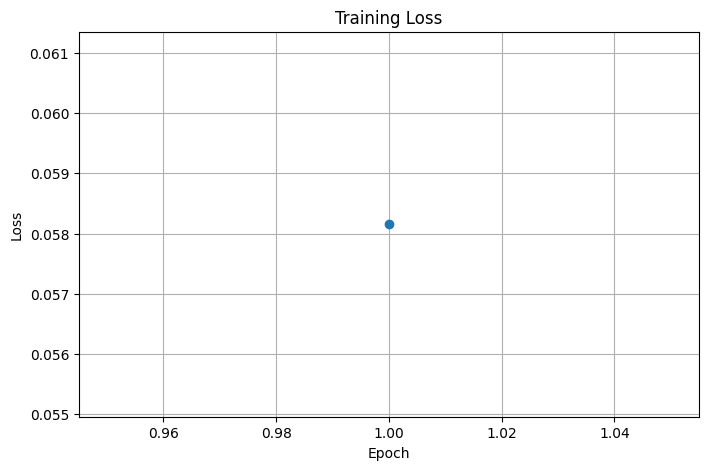

Evaluating model...

Accuracy: 0.9899375
              precision    recall  f1-score   support

    Not Spam       0.99      0.98      0.99      7655
        Spam       0.99      1.00      0.99      8345

    accuracy                           0.99     16000
   macro avg       0.99      0.99      0.99     16000
weighted avg       0.99      0.99      0.99     16000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [10]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ======================================

# Load Dataset

# ======================================

data = pd.read_csv(
r"C:\Users\goyal\Downloads\archive\combined_data.csv"
)

data = data.rename(columns={
"label": "spam"
})

data["spam"] = data["spam"].astype(int)

# Use 30,000 samples for final training

data = data.sample(n=80000, random_state=42)

print("Dataset loaded successfully")
print("Dataset shape:", data.shape)

# ======================================

# Train/Test Split

# ======================================

train_texts, test_texts, train_labels, test_labels = train_test_split(
data["text"],
data["spam"],
test_size=0.2,
random_state=42
)

# ======================================

# Tokenization

# ======================================

tokenizer = BertTokenizer.from_pretrained(
"bert-base-uncased"
)

print("Starting tokenization...")

train_encodings = tokenizer(
train_texts.tolist(),
truncation=True,
padding=True,
max_length=128
)

test_encodings = tokenizer(
test_texts.tolist(),
truncation=True,
padding=True,
max_length=128
)

print("Tokenization complete")

# ======================================

# Dataset Class

# ======================================
class SpamDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

# ======================================

# Data Loaders

# ======================================

train_dataset = SpamDataset(
train_encodings,
train_labels
)

test_dataset = SpamDataset(
test_encodings,
test_labels
)

train_loader = DataLoader(
train_dataset,
batch_size=8,
shuffle=True
)

test_loader = DataLoader(
test_dataset,
batch_size=8
)

# ======================================

# Device

# ======================================

device = torch.device(
"cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# ======================================

# Model

# ======================================

model = BertForSequenceClassification.from_pretrained(
"bert-base-uncased",
num_labels=2
)

print("Model loaded successfully")

model.to(device)

# ======================================

# Optimizer

# ======================================

optimizer = AdamW(
model.parameters(),
lr=2e-5
)

# ======================================

# Training

# ======================================

epochs = 2
loss_history = []

print("Starting training...")

for epoch in range(epochs):
    
    model.train()
    
    total_loss = 0

for batch in tqdm(
    train_loader,
    desc=f"Epoch {epoch+1}/{epochs}"
):

    optimizer.zero_grad()

    input_ids = batch["input_ids"].to(device)

    attention_mask = batch[
        "attention_mask"
    ].to(device)

    labels = batch[
        "labels"
    ].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss

    loss.backward()

    optimizer.step()

    total_loss += loss.item()

avg_loss = total_loss / len(train_loader)

loss_history.append(avg_loss)

print(
    f"Epoch {epoch+1}/{epochs} "
    f"Loss: {avg_loss:.4f}"
)


# ======================================

# Plot Loss

# ======================================

plt.figure(figsize=(8, 5))

plt.plot(
range(1, len(loss_history) + 1),
loss_history,
marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.savefig("loss_curve.png")
plt.show()

# ======================================

# Evaluation

# ======================================

print("Evaluating model...")

model.eval()

predictions = []
actual_labels = []

with torch.no_grad():

    for batch in test_loader:
    
        input_ids = batch[
            "input_ids"
        ].to(device)
    
        attention_mask = batch[
            "attention_mask"
        ].to(device)
    
        labels = batch[
            "labels"
        ].to(device)
    
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
    
        preds = torch.argmax(
            outputs.logits,
            dim=1
        )
    
        predictions.extend(
            preds.cpu().numpy()
        )
    
        actual_labels.extend(
            labels.cpu().numpy()
        )

# ======================================

# Results

# ======================================

accuracy = accuracy_score(
actual_labels,
predictions
)

print("\nAccuracy:", accuracy)

print(
classification_report(
actual_labels,
predictions,
target_names=[
"Not Spam",
"Spam"
]
)
)

# ======================================

# Save Model

# ======================================
model.save_pretrained("spam_classifier_model")
tokenizer.save_pretrained("spam_classifier_model")

print("Model saved successfully!")
